# ASOF joins: trades vs quotes, signing and spreads

Attaching the prevailing quote to every trade is *the* microstructure join. It
powers trade signing, effective and realized spread measurement, TCA and
toxicity analytics.

In h5i-db `asof_join` is a native SQL table function over time-sorted storage,
with no round-trip through pandas. Direction (`'backward'` or `'forward'`) and
a staleness tolerance are built in, and it composes with CTEs and window
functions like any other table.

In this recipe we work on a two-session tape with known ground truth and:

1. attach quotes to every trade, cross-checked against `pandas.merge_asof`,
2. sign trades Lee-Ready style and score the signing,
3. measure quoted, effective and realized spreads,
4. use tolerance to refuse stale quotes rather than silently mark against
   them.

## Terms used here

| term             | meaning |
| ---------------- | --- |
| ASOF join        | join each left row to the most recent right row at or before its timestamp |
| prevailing quote | the quote in force at the instant a trade printed |
| mid              | the average of bid and ask, the usual stand-in for "the price" |
| quoted spread    | ask minus bid as displayed, before any trade happens |
| effective spread | twice the distance from the trade price to the prevailing mid |
| realized spread  | the same measured against a mid some minutes later, so price drift is stripped out |
| trade signing    | inferring whether the buyer or the seller was the aggressor |
| Lee-Ready        | the standard signing rule: compare the trade price to the prevailing mid |
| tick test        | the fallback rule: compare the trade to the previous trade price |
| tolerance        | a maximum quote age, so a stale quote refuses to match rather than mislead |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import time

import numpy as np
import pandas as pd
import pyarrow as pa
import matplotlib.pyplot as plt

import h5i_db
from h5i_db import col, count_star, lit, sql_expr, when
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_asof"), create=True)

## 1. The data

Two sessions of top-of-book quotes from `cu.make_quotes`, one row per change
in the best bid or offer.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | quote timestamp, ascending |
| `symbol` | `string` | ticker |
| `bid`, `ask` | `float64` | best bid and offer |
| `bid_size`, `ask_size` | `int64` | displayed depth at each side |

In [2]:
quotes = cu.make_quotes(
    symbols=["AAPL", "MSFT", "NVDA"], days=2, quotes_per_day=1_000, seed=11
)
print(f"quotes: {quotes.num_rows:,} rows x {quotes.num_columns} columns")
quotes.to_pandas().head()

quotes: 6,368 rows x 6 columns


,ts,symbol,bid,ask,bid_size,ask_size
0,2026-06-01 13:30:04.799121+00:00,NVDA,256.53,256.55,400,200
1,2026-06-01 13:30:10.472342+00:00,AAPL,86.28,86.29,600,300
2,2026-06-01 13:30:13.476605+00:00,MSFT,219.73,219.75,300,100
3,2026-06-01 13:30:14.815696+00:00,NVDA,256.54,256.55,200,700
4,2026-06-01 13:30:17.442638+00:00,MSFT,219.71,219.77,100,400


To *score* trade signing we need trades whose true aggressor side we know, so
we derive the printed tape from the quote stream. Each trade takes the
prevailing bid or ask, 10% execute at the mid (the hard case for
classification), reporting latency runs 0.2–5ms, and every print keeps its
true `side`.

The derived tape adds a `trade_id` so later joins can address individual
prints.

In [3]:
qp = quotes.to_pandas()
rng = np.random.default_rng(23)
is_trade = rng.random(len(qp)) < 0.6
tr = qp.loc[is_trade, ["ts", "symbol", "bid", "ask"]].reset_index(drop=True)
n = len(tr)
buy = rng.random(n) < 0.5
at_mid = rng.random(n) < 0.10
px = np.where(buy, tr["ask"], tr["bid"])
px = np.where(at_mid, (tr["bid"] + tr["ask"]) / 2, px)
tr["price"] = px
tr["size"] = np.maximum(1, rng.lognormal(4.0, 1.2, n) // 100 * 100).astype("int64")
tr["side"] = np.where(buy, "B", "S")
tr["ts"] = (tr["ts"] + pd.to_timedelta(rng.uniform(0.2, 5.0, n), unit="ms")).dt.floor("us")
tr = tr.sort_values(["ts", "symbol"]).reset_index(drop=True)
tr["trade_id"] = np.arange(n, dtype="int64")

print(f"{len(tr):,} trades derived from {len(qp):,} quotes over 2 sessions")
tr[["ts", "symbol", "trade_id", "price", "size", "side"]].head()

3,827 trades derived from 6,368 quotes over 2 sessions


,ts,symbol,trade_id,price,size,side
0,2026-06-01 13:30:13.480432+00:00,MSFT,0,219.730,1,S
1,2026-06-01 13:30:14.819772+00:00,NVDA,1,256.550,1,B
2,2026-06-01 13:30:18.039449+00:00,AAPL,2,86.290,1,B
3,2026-06-01 13:30:20.607466+00:00,AAPL,3,86.275,1,S
4,2026-06-01 13:30:28.798380+00:00,MSFT,4,219.670,1,B


Alongside them we store a `marks` table: each trade's timestamp shifted
forward by 5 minutes. It will drive the realized-spread lookup in section 4.

In [4]:
ts_field = pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False)
trade_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("trade_id", pa.int64()),
     pa.field("price", pa.float64()), pa.field("size", pa.int64()),
     pa.field("side", pa.string())]
)
db.create_table("trades", trade_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("trades", pa.Table.from_pandas(
    tr[["ts", "symbol", "trade_id", "price", "size", "side"]], preserve_index=False
).cast(trade_schema))

quote_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("bid", pa.float64()),
     pa.field("ask", pa.float64()), pa.field("bid_size", pa.int64()),
     pa.field("ask_size", pa.int64())]
)
db.create_table("quotes", quote_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("quotes", quotes.cast(quote_schema))

marks = tr[["ts", "symbol", "trade_id"]].copy()
marks["ts"] = marks["ts"] + pd.Timedelta(minutes=5)
marks = marks.sort_values(["ts", "symbol"])
mark_schema = pa.schema(
    [ts_field, pa.field("symbol", pa.string()), pa.field("trade_id", pa.int64())]
)
db.create_table("marks", mark_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("marks", pa.Table.from_pandas(marks, preserve_index=False).cast(mark_schema))

db.tables()

['marks', 'quotes', 'trades']

## 2. The join itself

`asof_join(left, right, left_ts, right_ts, by_key)` gives, for each trade, the
latest quote at or before it, per symbol.

Right-side columns that collide get a `_right` suffix. Here the quote's own
timestamp arrives as `ts_right`, so trade time minus `ts_right` is the quote's
age. Because both tables are stored time-ordered, there is no sort phase to
pay for.

In [5]:
t0 = time.perf_counter()
TQ = db.table("trades").join_asof(db.table("quotes"), on="ts", by="symbol")

joined = TQ.select(
    "ts", "symbol", "trade_id", "price", "side", "ts_right", "bid", "ask"
).sort("trade_id").to_pandas()
elapsed_ms = (time.perf_counter() - t0) * 1e3
print(f"{len(joined):,} trades matched against {len(qp):,} quotes "
      f"in {elapsed_ms:.1f} ms")
joined.head(5)

3,827 trades matched against 6,368 quotes in 17.5 ms


,ts,symbol,trade_id,price,side,ts_right,bid,ask
0,2026-06-01 13:30:13.480432+00:00,MSFT,0,219.730,S,2026-06-01 13:30:13.476605+00:00,219.73,219.75
1,2026-06-01 13:30:14.819772+00:00,NVDA,1,256.550,B,2026-06-01 13:30:14.815696+00:00,256.54,256.55
2,2026-06-01 13:30:18.039449+00:00,AAPL,2,86.290,B,2026-06-01 13:30:18.038985+00:00,86.27,86.29
3,2026-06-01 13:30:20.607466+00:00,AAPL,3,86.275,S,2026-06-01 13:30:20.604144+00:00,86.27,86.28
4,2026-06-01 13:30:28.798380+00:00,MSFT,4,219.670,B,2026-06-01 13:30:28.796644+00:00,219.62,219.67


Trust, but verify. The same alignment through `pandas.merge_asof` must produce
identical quotes for every trade.

In [6]:
left = tr[["ts", "symbol", "trade_id"]].sort_values("ts")
left["ts"] = left["ts"].astype("datetime64[us, UTC]")  # match arrow's us resolution
ref = pd.merge_asof(
    left, qp[["ts", "symbol", "bid", "ask"]],
    on="ts", by="symbol", direction="backward",
)
cmp = joined.merge(ref[["trade_id", "bid", "ask"]], on="trade_id", suffixes=("", "_pd"))
assert len(cmp) == len(tr)
assert np.allclose(cmp["bid"], cmp["bid_pd"]) and np.allclose(cmp["ask"], cmp["ask_pd"])
print(f"asof_join matches pandas.merge_asof on all {len(cmp):,} trades")

asof_join matches pandas.merge_asof on all 3,827 trades


There is also a keyword spelling, handy when the ASOF join is one clause of a
larger statement. Two current limitations are worth knowing: it requires bare
table names with no aliases, and the output columns are referenced unqualified.

In [7]:
db.sql(
    """
    SELECT ts, symbol, price, bid, ask
    FROM trades ASOF JOIN quotes
    MATCH_CONDITION (trades.ts >= quotes.ts) ON trades.symbol = quotes.symbol
    LIMIT 3
    """
).to_pandas()

,ts,symbol,price,bid,ask
0,2026-06-01 13:30:13.480432+00:00,MSFT,219.73,219.73,219.75
1,2026-06-01 13:30:14.819772+00:00,NVDA,256.55,256.54,256.55
2,2026-06-01 13:30:18.039449+00:00,AAPL,86.29,86.27,86.29


## 3. Lee-Ready trade signing

The quote rule comes first: above the mid is a buy, below is a sell. Exact-mid
prints fall through to the tick test, here via `lag(price)`. Strict Lee-Ready
wants the last *different* price, a refinement that matters little on this
tape.

It all fits in one statement: the asof join feeds a window function, which
feeds a `CASE` ladder.

In [8]:
PREV_PX = sql_expr("lag(price)").over(partition_by="symbol", order_by="ts")

signed = (
    TQ.select(
        "ts", "symbol", "trade_id", "price", "size", "side", "bid", "ask",
        mid=(col("bid") + col("ask")) / 2,
    )
    .with_columns(prev_px=PREV_PX)
    .with_columns(
        lr_side=when(col("price") > col("mid")).then(lit("B"))
        .when(col("price") < col("mid")).then(lit("S"))
        .when(col("price") > col("prev_px")).then(lit("B"))
        .when(col("price") < col("prev_px")).then(lit("S"))
        .otherwise(lit("U"))
    )
    .to_pandas()
)

overall = (signed["lr_side"] == signed["side"]).mean()
quote_rule = signed[signed["price"] != signed["mid"]]
mid_prints = signed[signed["price"] == signed["mid"]]
print(f"overall accuracy      : {overall:.1%}")
print(f"quote-rule prints     : {(quote_rule['lr_side'] == quote_rule['side']).mean():.1%} "
      f"of {len(quote_rule):,}")
print(f"mid prints (tick test): {(mid_prints['lr_side'] == mid_prints['side']).mean():.1%} "
      f"of {len(mid_prints):,}")
pd.crosstab(signed["lr_side"], signed["side"], margins=True)

overall accuracy      : 93.3%
quote-rule prints     : 100.0% of 3,339
mid prints (tick test): 47.3% of 488


side,B,S,All
lr_side,,,
B,1770,109,1879
S,115,1800,1915
U,16,17,33
All,1901,1926,3827


The quote rule is near-perfect. Its only failure mode is a quote update
landing inside the trade's few-ms reporting latency. Mid prints fall back to
the roughly coin-flip tick test.

On real TAQ data the quote-rule share is lower and overall accuracy lands
around 85–90%. The split above shows exactly where the errors live.

## 4. Quoted, effective and realized spread

Three measures, three formulas:

- quoted is `ask - bid` at the prevailing quote;
- effective is `2·|price - mid|`, what aggressors actually paid;
- realized is `2·d·(price - mid₊₅ₘ)`, what liquidity providers actually kept,
  using the mid 5 minutes later.

That 5-minutes-later mid is the `marks` table asof-joined **forward**: the
first quote at or after trade time plus 5 minutes. Everything lands in one
statement, in basis points of the mid.

In [9]:
MID = (col("bid") + col("ask")) / 2

j = TQ.select("symbol", "trade_id", "price", "side", "bid", "ask", mid=MID)
m = (
    db.table("marks")
    .join_asof(db.table("quotes"), on="ts", by="symbol", direction="forward")
    .select("trade_id", mid_5m=MID)
)

# .join() aliases the sides l and r: l is the trade-time join, r the mark.
px = col("price", relation="l")
mid = col("mid", relation="l")
mid_5m = col("mid_5m", relation="r")
direction = when(col("side", relation="l") == "B").then(lit(1)).otherwise(lit(-1))

spreads = (
    j.join(m, on="trade_id")
    .filter(mid_5m.is_not_null())
    .group_by(col("symbol", relation="l").alias("symbol"))
    .agg(
        quoted_bps=((col("ask", relation="l") - col("bid", relation="l")) / mid).mean() * 1e4,
        effective_bps=(2 * (px - mid).abs() / mid).mean() * 1e4,
        realized_bps=(2 * direction * (px - mid_5m) / mid).mean() * 1e4,
        n_trades=count_star(),
    )
    .sort("symbol")
    .to_pandas()
)
spreads

,symbol,quoted_bps,effective_bps,realized_bps,n_trades
0,AAPL,1.775744,1.581595,2.220676,1229
1,MSFT,1.742132,1.555869,-0.421159,1335
2,NVDA,1.776693,1.602655,1.263033,1212


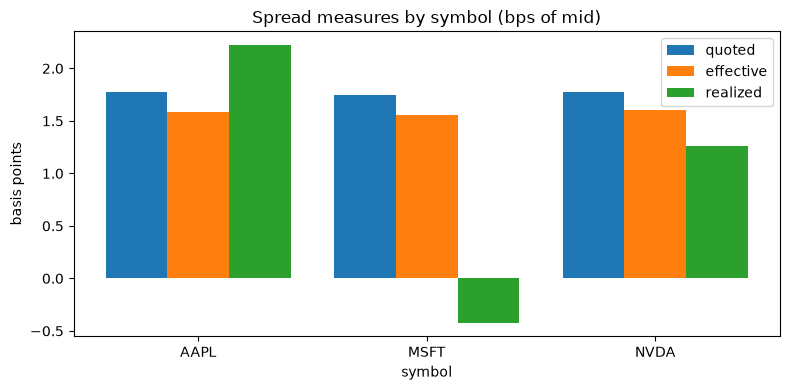

In [10]:
x = np.arange(len(spreads))
w = 0.27
fig, ax = plt.subplots(figsize=(8, 4))
for i, measure in enumerate(("quoted_bps", "effective_bps", "realized_bps")):
    ax.bar(x + (i - 1) * w, spreads[measure], width=w, label=measure.replace("_bps", ""))
ax.set_xticks(x, spreads["symbol"])
ax.set_title("Spread measures by symbol (bps of mid)")
ax.set_xlabel("symbol")
ax.set_ylabel("basis points")
ax.legend()
fig.tight_layout()

Effective sits a notch below quoted because 10% of prints execute at the mid.

Realized shows no *systematic* gap to effective. This synthetic flow carries
no information, so on average the mid does not drift against the liquidity
provider after the trade. The per-symbol estimates scatter around effective
because 5-minute mid volatility dwarfs the spread, and that noisiness is
faithful to the real-world estimator too.

On a real tape realized sits systematically *below* effective. The gap,
`2·d·(mid₊₅ₘ − mid)`, is price impact, and this decomposition is the standard
way to measure adverse-selection cost.

## 5. Tolerance: refuse stale quotes

By default the asof join reaches arbitrarily far back. Against a gappy quote
feed, whether from outages or subsampled vendor files, that silently marks
trades against minutes-old NBBO.

The optional tolerance bounds the lookback. It is in raw microseconds, like
every raw time argument in h5i-db. Unmatched trades keep NULL quote columns,
so staleness becomes *visible* and countable. Below we thin the quote feed to
25% to simulate the problem.

In [11]:
qs = qp[rng.random(len(qp)) < 0.25].sort_values(["ts", "symbol"])
db.create_table("quotes_sparse", quote_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append("quotes_sparse", pa.Table.from_pandas(qs, preserve_index=False).cast(quote_schema))

for label, tol in [("no tolerance", None), ("60s tolerance", 60_000_000),
                   ("5s tolerance", 5_000_000)]:
    r = (
        db.table("trades")
        .join_asof(db.table("quotes_sparse"), on="ts", by="symbol", tolerance=tol)
        .select(n=count_star(), matched=col("bid").count())
        .to_pandas()
    )
    print(f"{label:>13}: {r['matched'][0]:,} of {r['n'][0]:,} trades matched "
          f"({r['matched'][0] / r['n'][0]:.1%})")

 no tolerance: 3,823 of 3,827 trades matched (99.9%)
60s tolerance: 2,671 of 3,827 trades matched (69.8%)
 5s tolerance: 1,206 of 3,827 trades matched (31.5%)


Without a tolerance every trade gets *some* quote, however stale. With a
freshness requirement, the trades whose prevailing quote is too old honestly
report NULL instead. In production that NULL share is a data-quality metric
worth alerting on.

## Takeaways

- `.join_asof(other, on="ts", by="symbol")` is the whole trades-vs-quotes
  alignment: per-key, time-correct, streaming on sorted storage, and it agrees
  with `pandas.merge_asof` row for row. Both sides must be plain unpinned
  tables, because the underlying `asof_join` takes names, so filter *after* the
  join.
- Direction and tolerance are first-class. `direction="forward"` fetched the
  5-minutes-later mid for realized spread, and a microsecond `tolerance`
  turned stale-quote marking into visible, countable NULLs. Sweeping the
  tolerance is a Python loop rather than three hand-written statements.
  Colliding right columns get `_right`.
- The joined frame composes. Hold it in a variable, here `TQ`, and both
  Lee-Ready signing and the quoted/effective/realized decomposition build on
  it: `when().then()` for the CASE ladder, `sql_expr("lag(price)").over(...)`
  for the tick test.
- Scoring against ground truth requires a tape where trades and quotes share
  one price process. Worth remembering before benchmarking signing accuracy on
  any synthetic data.

In [12]:
db.close()